# 04. 신도시별·시간대별 교통약자 사고 비교 분석

In [ ]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import matplotlib.font_manager as fm

## 1) 데이터 불러오기

In [ ]:
# 격자 데이터 읽기 (geo)
geo1 = gpd.read_file("01._격자_(4개_시·구).geojson")
geo2 = gpd.read_file("02._격자_(하남교산).geojson")
geo3 = gpd.read_file("08.상세도로망_네트워크.geojson")

# 독립변수 데이터 읽기 (Independent Variable)
iv_peo1 = pd.read_csv("03._성연령별_거주인구(격자).csv")
iv_peo2 = pd.read_csv("04._성연령별_유동인구.csv")
iv_peo3 = pd.read_csv("05._시간대별_직장인구.csv")
iv_peo4 = pd.read_csv("06._시간대별_방문인구.csv")
iv_peo5 = pd.read_csv("07._주중주말_서비스인구.csv")

iv_area1 = pd.read_csv("14._어린이보호구역.csv")
iv_area2 = pd.read_csv("15._학교현황.csv")
iv_area3 = pd.read_csv("16._유치원현황.csv")
iv_area4 = pd.read_csv("17._어린이집현황.csv")
iv_area5 = pd.read_csv("18._횡단보도_위치정보.csv")
iv_area6 = pd.read_csv("19._버스정류장_위치정보.csv")

iv_risk1 = pd.read_csv("09._평균속도.csv")
iv_risk2 = pd.read_csv("10._추정교통량.csv")
iv_risk3 = pd.read_csv("11._혼잡빈도강도.csv")
iv_risk4 = pd.read_csv("12._혼잡시간강도.csv")

iv_fac1 = pd.read_csv("20._CCTV_현황.csv")
iv_fac2 = pd.read_csv("21._과속방지턱_현황.csv")

dv = gpd.read_file("13._교통사고이력.geojson")

# 토지 이용 계획 데이터 읽기 (Land Use Plan)
lup1 = gpd.read_file("22._토지이용계획도_(4개_신도시).geojson")
lup2 = gpd.read_file("23._토지이용계획도_(하남교산).geojson")

In [ ]:
font_path = 'NanumGothic.ttf'
fm.fontManager.addfont(font_path)
font_name = fm.FontProperties(fname=font_path).get_name()
plt.rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid", rc={"font.family": font_name, "axes.unicode_minus": False})

## 2) 결측치 처리

In [ ]:
dv_clean = dv.dropna(subset=['age_group', 'injury_svrity'])

print(f"삭제 전 데이터 건수: {len(dv)}")
print(f"삭제 후 데이터 건수: {len(dv_clean)}")

삭제 전 데이터 건수: 10821
삭제 후 데이터 건수: 10400


In [ ]:
# 1. 연령대(age_group) 컬럼에 어떤 값들이 있는지 확인
print(" 연령대 고유값 확인:", dv_clean['age_group'].unique())

# 2. 위에서 확인한 텍스트 중 '어린이'에 해당하는 텍스트를 찾아 필터링
dv_child = dv_clean[dv_clean['age_group'] == '12세 이하']
dv_old = dv_clean[dv_clean['age_group'].isin(['61-64세', '65세 이상'])]

print(f"\n 전체 사고 {len(dv)}건 중 어린이 사고는 {len(dv_child)}건 입니다.")
print(f"\n 전체 사고 {len(dv)}건 중 노약자 사고는 {len(dv_old)}건 입니다.")

 연령대 고유값 확인: ['41-50세' '51-60세' '31-40세' '21-30세' '65세 이상' '61-64세' '13-20세' '12세 이하'
 '기타불명']

 전체 사고 10821건 중 어린이 사고는 212건 입니다.

 전체 사고 10821건 중 노약자 사고는 2027건 입니다.


## 3) 사고 지점의 신도시 매핑

In [8]:
# 2. 좌표계 통일 (공간 결합을 위해 필수)
if dv.crs != lup1.crs:
    dv = dv.to_crs(lup1.crs)

In [ ]:
# 4. zoneName을 기반으로 4개 신도시명으로 그룹화하는 함수
def mapping_city(name):
    name = str(name)
    if '동탄' in name: return '동탄신도시'
    elif '위례' in name: return '위례신도시'
    elif '미사' in name: return '하남미사'
    elif '판교' in name: return '판교신도시'
    else: return '기타'

# 3. 공간 결합 (사고 지점에 신도시 정보 매칭)
# 사고 데이터(dv)에 해당 사고가 발생한 구역의 'zoneName' 정보를 붙임
dv_mapped = gpd.sjoin(dv, lup1[['zoneName', 'geometry']], how='left', predicate='within')
dv_mapped['new_city_name'] = dv_mapped['zoneName'].apply(mapping_city)

## 4) 비교 대상 그룹 구성

In [ ]:
# 5. 어린이 사고 데이터 필터링 및 '기타' 지역 제거
dv_child = dv_mapped[(dv_mapped['new_city_name'] != '기타') & (dv_mapped['age_group'].str.contains('12세 이하', na=False))]
dv_old = dv_mapped[(dv_mapped['new_city_name'] != '기타') & (dv_mapped['age_group'].str.contains('65세 이상', na=False))]

## 5) 어린이 사고 시간대 및 지역별 분포

/tmp/ipykernel_443/3965688273.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=dv_child, x='acc_time',


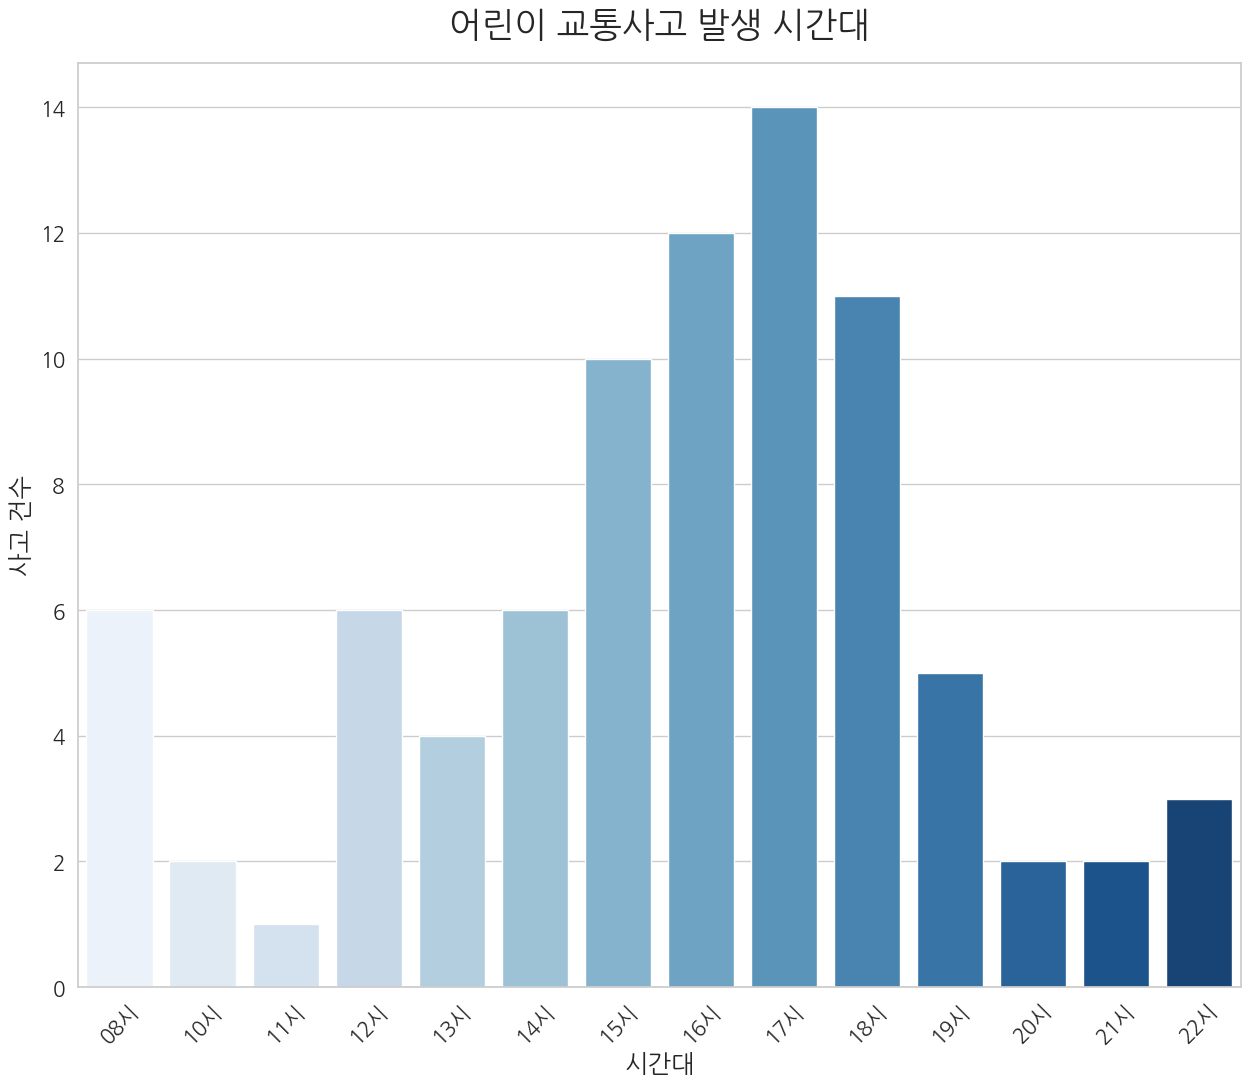

/tmp/ipykernel_443/3965688273.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=dv_child, y='new_city_name',


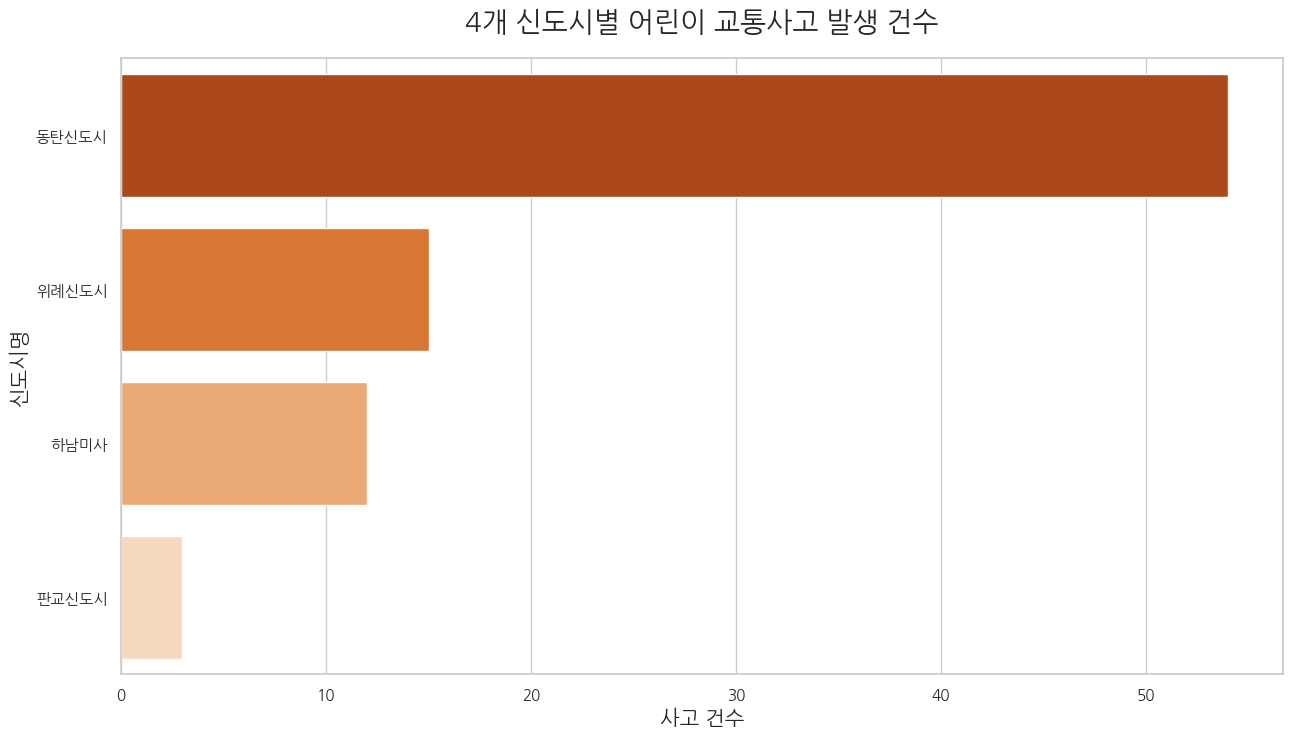

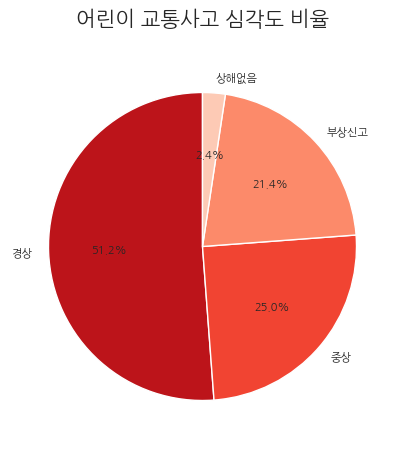

In [11]:
# --- EDA 시각화 (신도시명 적용) ---

# ① 어린이 사고 집중 시간대 분석 (acc_time)
fig, axes = plt.subplots(figsize=(15, 12))
sns.countplot(data=dv_child, x='acc_time', 
              order=sorted(dv_child['acc_time'].dropna().unique()), 
              palette='Blues')
plt.title('어린이 교통사고 발생 시간대', fontsize=25, fontweight='bold', pad=20)
plt.xlabel('시간대', fontsize=18)
plt.ylabel('사고 건수', fontsize=18)
plt.xticks(rotation=45, fontsize=15)
plt.yticks(fontsize=15)
plt.show()


# ② 4개 신도시별 어린이 사고 발생 규모 비교 (sgg 대신 new_city_name 사용)
plt.figure(figsize=(15, 8)) 
sns.countplot(data=dv_child, y='new_city_name', 
              order=dv_child['new_city_name'].value_counts().index, 
              palette='Oranges_r')
plt.title('4개 신도시별 어린이 교통사고 발생 건수', fontsize=20, fontweight='bold', pad=20)
plt.xlabel('사고 건수', fontsize=15)
plt.ylabel('신도시명', fontsize=15)
plt.savefig('신도시별_어린이_교통사고_발생건수.png', dpi=300)

# ③ 어린이 사고의 심각도 파악 (injury_svrity)
# 사고 심각도별 비율을 파이 차트로 시각화하여 위험성 강조
plt.figure(figsize=(5, 5))
severity_counts = dv_child['injury_svrity'].value_counts()
plt.pie(severity_counts, labels=severity_counts.index, autopct='%1.1f%%', 
        startangle=90, colors=sns.color_palette('Reds_r', len(severity_counts)),
        textprops={'fontsize': 8}) 
plt.title('어린이 교통사고 심각도 비율', fontsize=15, fontweight='bold', pad=20)
plt.show()

## 6) 노인 사고 시간대 및 지역별 분포

/tmp/ipykernel_443/503964318.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=dv_old, x='acc_time',


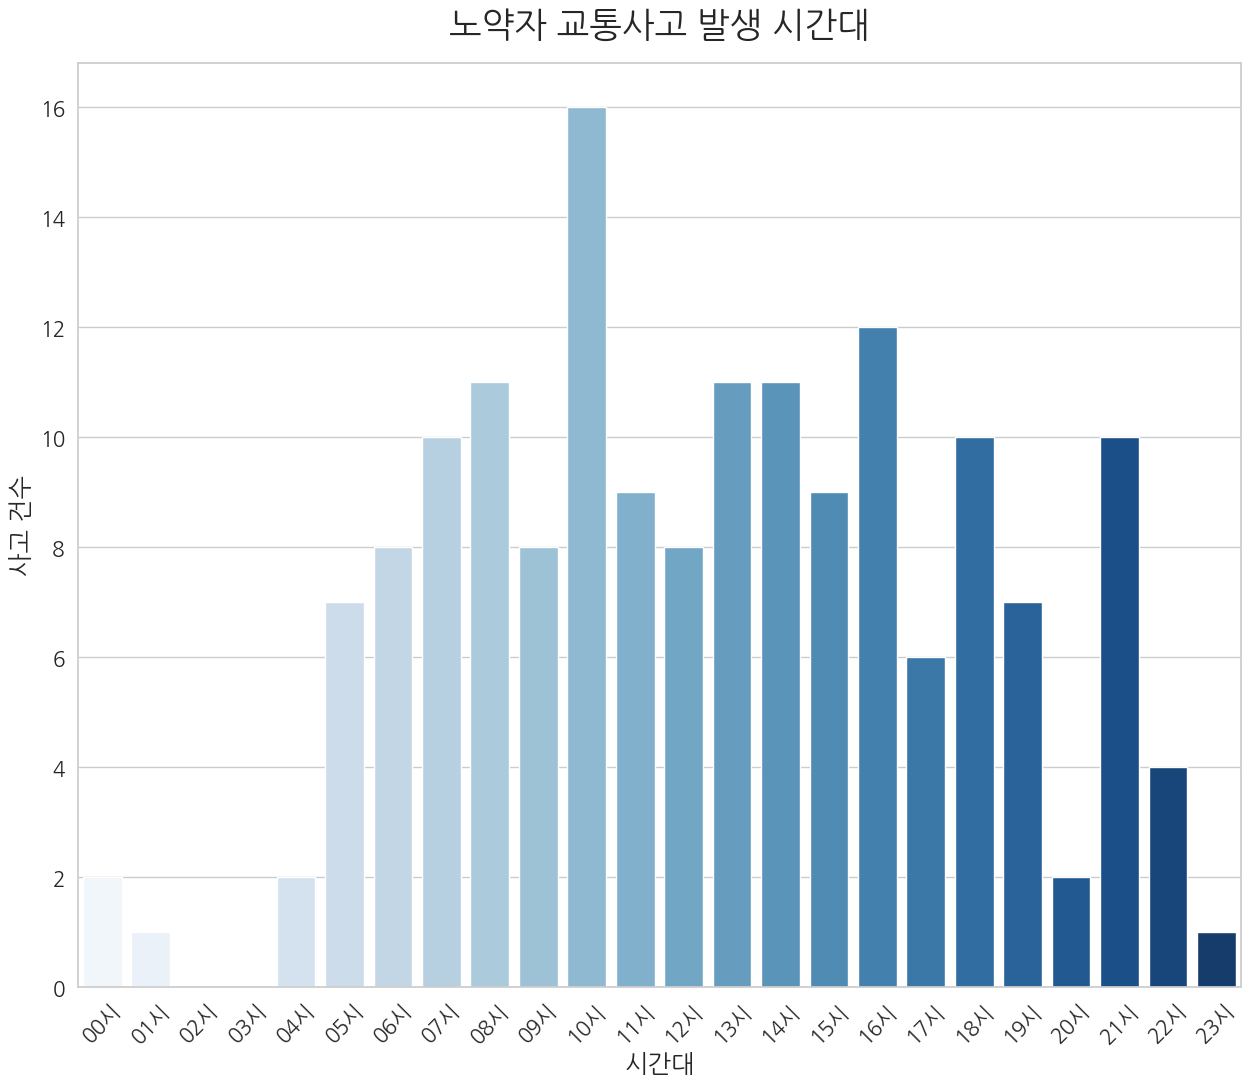

/tmp/ipykernel_443/503964318.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=dv_old, y='new_city_name',


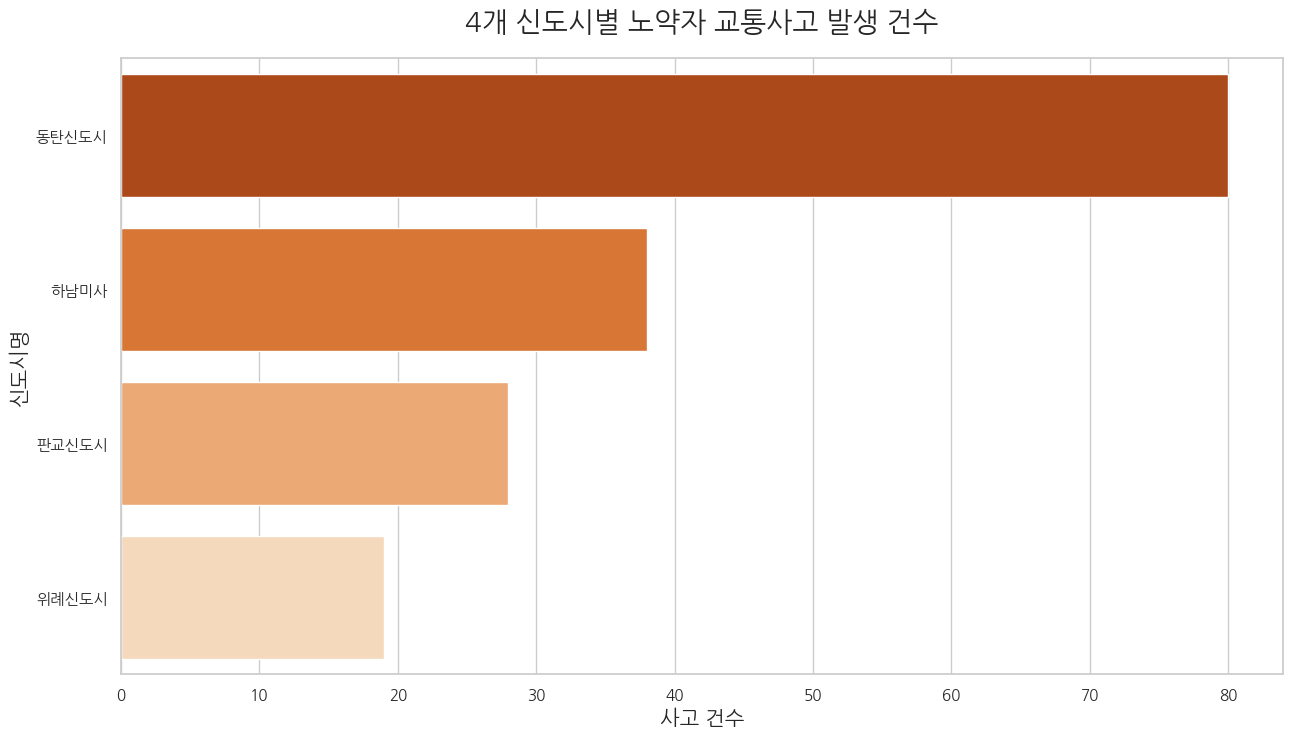

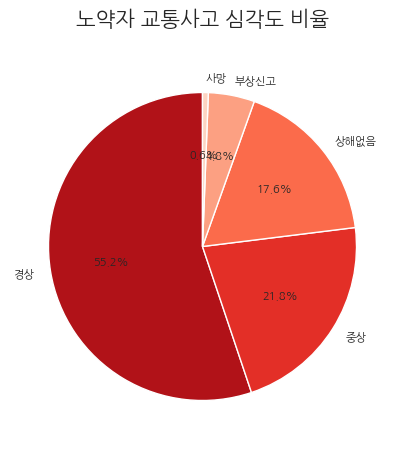

In [ ]:
# ① 노약자 사고 집중 시간대 분석 (acc_time)
fig, axes = plt.subplots(figsize=(15, 12))

#  00~23시 전체 시간대 리스트를 강제로 생성 
# 데이터 원본의 acc_time 형태('08', 8, '08시' 등)를 자동으로 파악하여 형태를 맞춤
sample_val = dv_old['acc_time'].dropna().iloc[0]

if isinstance(sample_val, (int, float)):
    all_hours = list(range(24))
elif isinstance(sample_val, str):
    if '시' in sample_val:
        all_hours = [f"{i:02d}시" for i in range(24)]
    elif sample_val.isdigit():
        pad_len = len(sample_val) # '8'이면 1자리, '08'이면 2자리 유지
        all_hours = [str(i).zfill(pad_len) for i in range(24)]
    else:
        all_hours = [str(i).zfill(2) for i in range(24)]
else:
    all_hours = [str(i).zfill(2) for i in range(24)]


#  order 파라미터에 데이터의 고유값이 아닌 all_hours 전체 리스트 전달 
sns.countplot(data=dv_old, x='acc_time', 
              order=all_hours, 
              palette='Blues')

plt.title('노약자 교통사고 발생 시간대', fontsize=25, fontweight='bold', pad=20)
plt.xlabel('시간대', fontsize=18)
plt.ylabel('사고 건수', fontsize=18)
plt.xticks(rotation=45, fontsize=15)
plt.yticks(fontsize=15)
plt.show()

# ② 4개 신도시별 어린이 사고 발생 규모 비교 (sgg 대신 new_city_name 사용)
plt.figure(figsize=(15, 8)) 
sns.countplot(data=dv_old, y='new_city_name', 
              order=dv_old['new_city_name'].value_counts().index, 
              palette='Oranges_r')
plt.title('4개 신도시별 노약자 교통사고 발생 건수', fontsize=20, fontweight='bold', pad=20)
plt.xlabel('사고 건수', fontsize=15)
plt.ylabel('신도시명', fontsize=15)

# ③ 어린이 사고의 심각도 파악 (injury_svrity)
# 사고 심각도별 비율을 파이 차트로 시각화하여 위험성 강조
plt.figure(figsize=(5, 5))
severity_counts = dv_old['injury_svrity'].value_counts()
plt.pie(severity_counts, labels=severity_counts.index, autopct='%1.1f%%', 
        startangle=90, colors=sns.color_palette('Reds_r', len(severity_counts)),
        textprops={'fontsize': 8}) 
plt.title('노약자 교통사고 심각도 비율', fontsize=15, fontweight='bold', pad=20)
plt.show()

## 7) 어린이·노인 시간대별 통합 비교

In [ ]:
# 1. 데이터에 구분 컬럼 추가 및 병합
dv_child['target'] = '어린이'
dv_old['target'] = '노약자'
df_combined = pd.concat([dv_child, dv_old], axis=0)

# 시간대 포맷 통일 (00~23시 리스트 생성 로직 유지)
sample_val = df_combined['acc_time'].dropna().iloc[0]
if isinstance(sample_val, (int, float)):
    all_hours = list(range(24))
elif isinstance(sample_val, str):
    if '시' in sample_val:
        all_hours = [f"{i:02d}시" for i in range(24)]
    elif sample_val.isdigit():
        pad_len = len(sample_val)
        all_hours = [str(i).zfill(pad_len) for i in range(24)]
    else:
        all_hours = [str(i).zfill(2) for i in range(24)]
else:
    all_hours = [str(i).zfill(2) for i in range(24)]

## 8) 시간대별 누적 사고 시각화

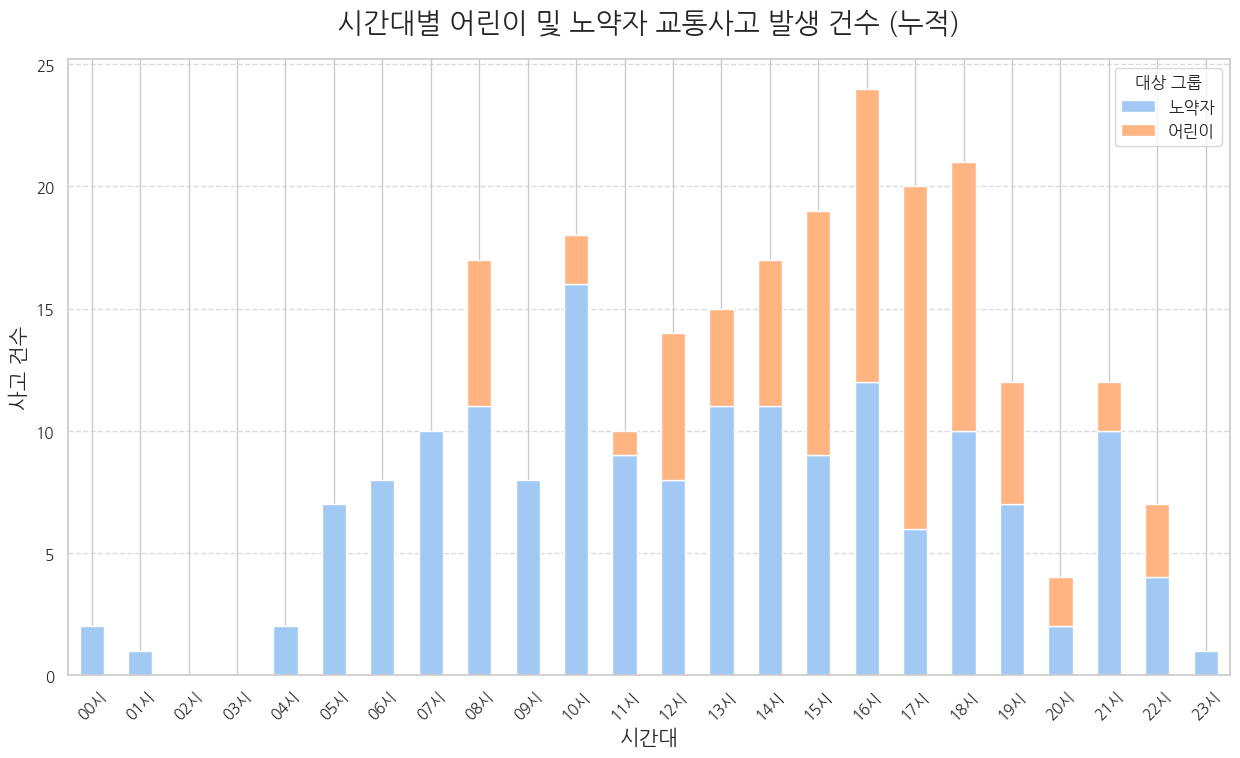

In [ ]:
# 데이터 집계: 시간대와 대상별 count
time_counts = df_combined.groupby(['acc_time', 'target']).size().unstack(fill_value=0)

# 0~23시 순서 보장 (데이터에 없는 시간대는 0으로 채움)
time_counts = time_counts.reindex(all_hours, fill_value=0)

time_counts.plot(kind='bar', stacked=True, figsize=(15, 8), color=['#A1C9F4', '#FFB482'])

plt.title('시간대별 어린이 및 노약자 교통사고 발생 건수 (누적)', fontsize=20, fontweight='bold', pad=20)
plt.xlabel('시간대', fontsize=15)
plt.ylabel('사고 건수', fontsize=15)
plt.xticks(rotation=45)
plt.legend(title='대상 그룹', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()